In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy as stats
from pathlib import Path
import missingno as msno


1. Understanding the types of missingness
   
2. Detection and profiling
   
3. Techniques — from basic to advanced
   
   3a. Deletion (baseline)

   3b. Statistical imputation

   3c. KNN imputation

   3d. Iterative / matrix imputation (MICE-style)

   3e. Missingness indicators (for MNAR)

   3f. Tree models + native NaN handling

4. Production-standard pipeline

5. Runtime missing-value monitoring



Decision guide
Scenario.               Recommended technique

MCAR,                   <5% missingListwise deletion or median impute

MAR,numeric             KNN or IterativeImputer

MAR,many cols           IterativeImputer with RF estimator

MNAR                    Missingness indicator + any imputer

Tabular + tree          modelLightGBM / XGBoost native NaN

Production serving      Sklearn Pipeline with joblib

MonitoringPer-column    rate drift alerts
   


Before choosing a technique, you must diagnose why data is missing — the mechanism matters.

MCAR (Missing Completely At Random) — the missing values have no relationship to any variable. A sensor randomly fails. Safe to drop rows, though imputation still reduces waste.

MAR (Missing At Random) — missingness depends on other observed variables but not on the missing value itself. Example: older survey respondents tend to skip income questions. You can impute from the observed variables.

MNAR (Missing Not At Random) — the missing value is related to its own unobserved magnitude. High earners skip income fields because they earn a lot. Simple imputation is biased; you need domain modeling or indicator flags.

In [2]:
TITANIC_DATA_PATH   = Path('../practice/datasets/kaggle/titanic/train.csv')
TITANIC_MODEL_DIR   = Path('../practice/models/titanic'); TITANIC_MODEL_DIR.mkdir(exist_ok=True)
TITANIC_OUTPUT_DIR  = Path('../practice/outputs/titanic'); TITANIC_OUTPUT_DIR.mkdir(exist_ok=True)

In [3]:
titanic_df=pd.read_csv(TITANIC_DATA_PATH)

In [5]:
titanic_df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


Detecting and profiling

In [4]:
missing=pd.DataFrame({"count":titanic_df.isna().sum(),
                      "pct":titanic_df.isna().mean().mul(100).round(2)
                      }).query("count>0").sort_values('pct',ascending=False)
missing

,count,pct
Cabin,687,77.10
Age,177,19.87
Embarked,2,0.22


In [7]:
# missingness correlation helps to identify MAR
missing_matrix=titanic_df.isna().astype(int)
missing_matrix

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,0,0,0,0,0,0,0,0,0,0,1,0
1,0,0,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,1,0
3,0,0,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,0,0,0,0,0,0,0,0,0,1,0
887,0,0,0,0,0,0,0,0,0,0,0,0
888,0,0,0,0,0,1,0,0,0,0,1,0
889,0,0,0,0,0,0,0,0,0,0,0,0


<Axes: >

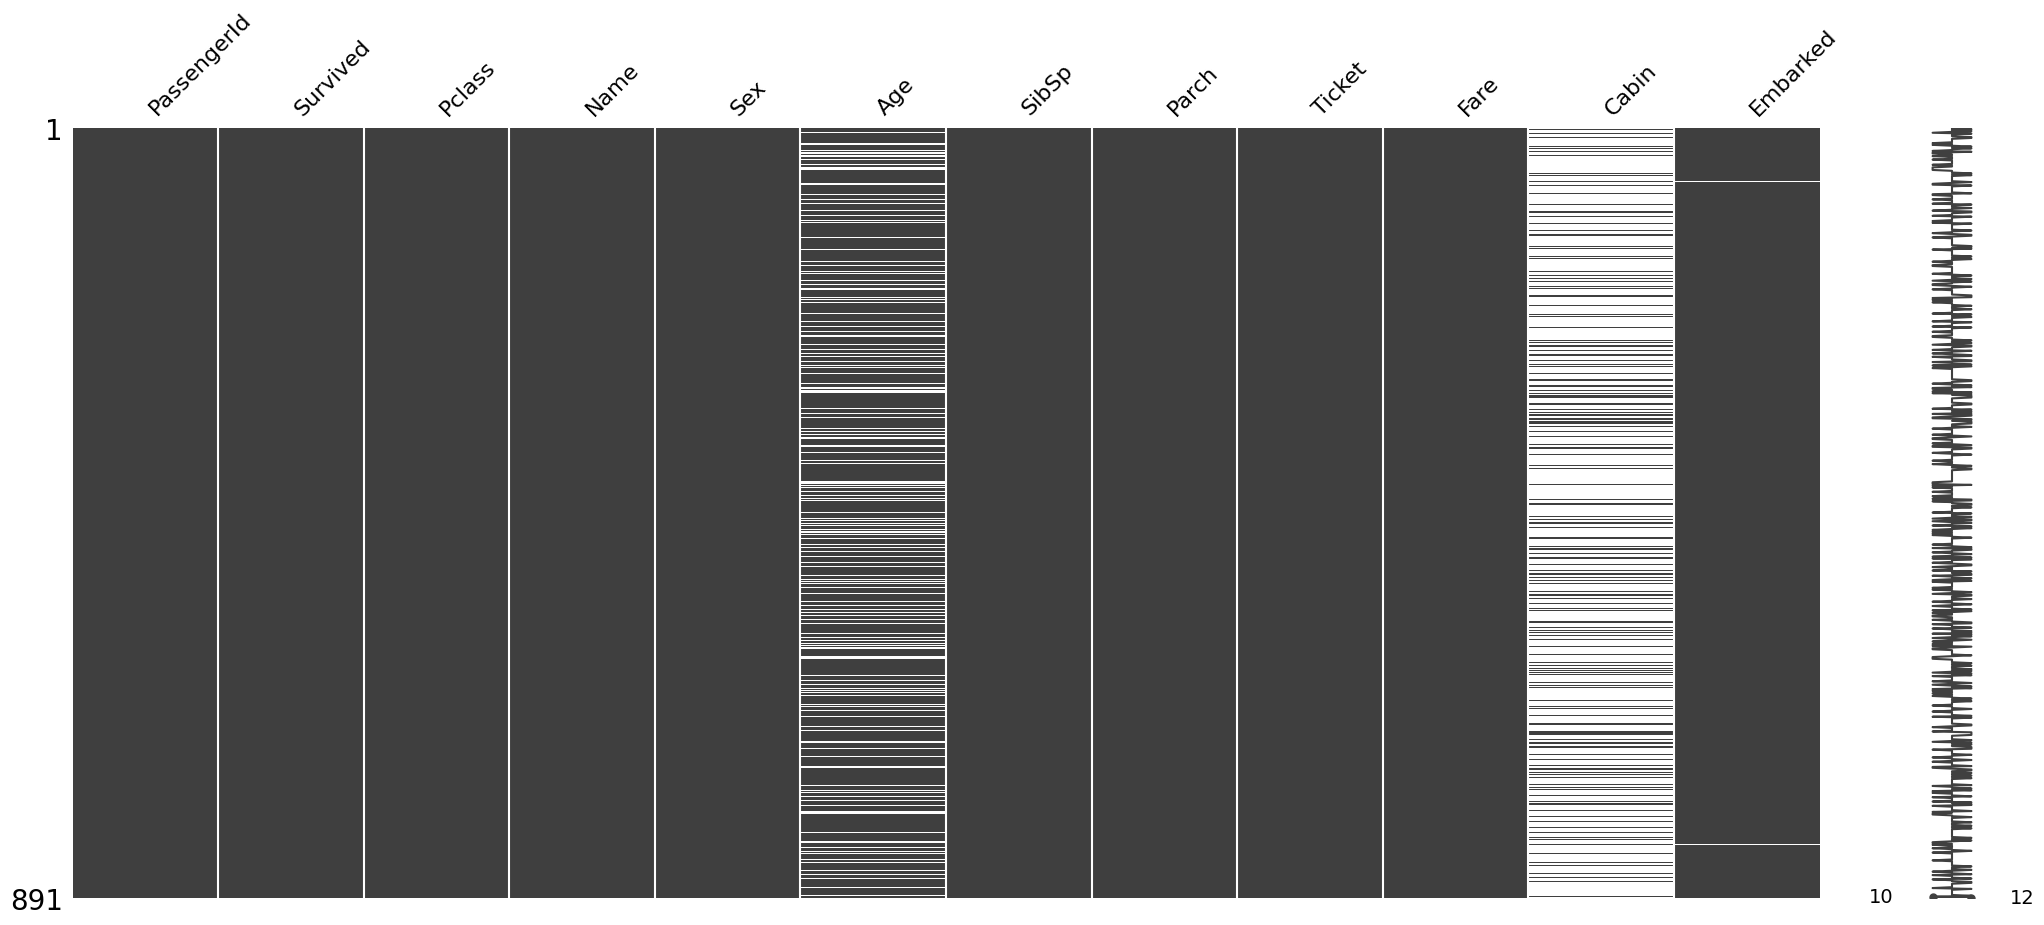

In [9]:
# heatmap( deb only ) reveals the missing patterns
msno.matrix(titanic_df)

<Axes: >

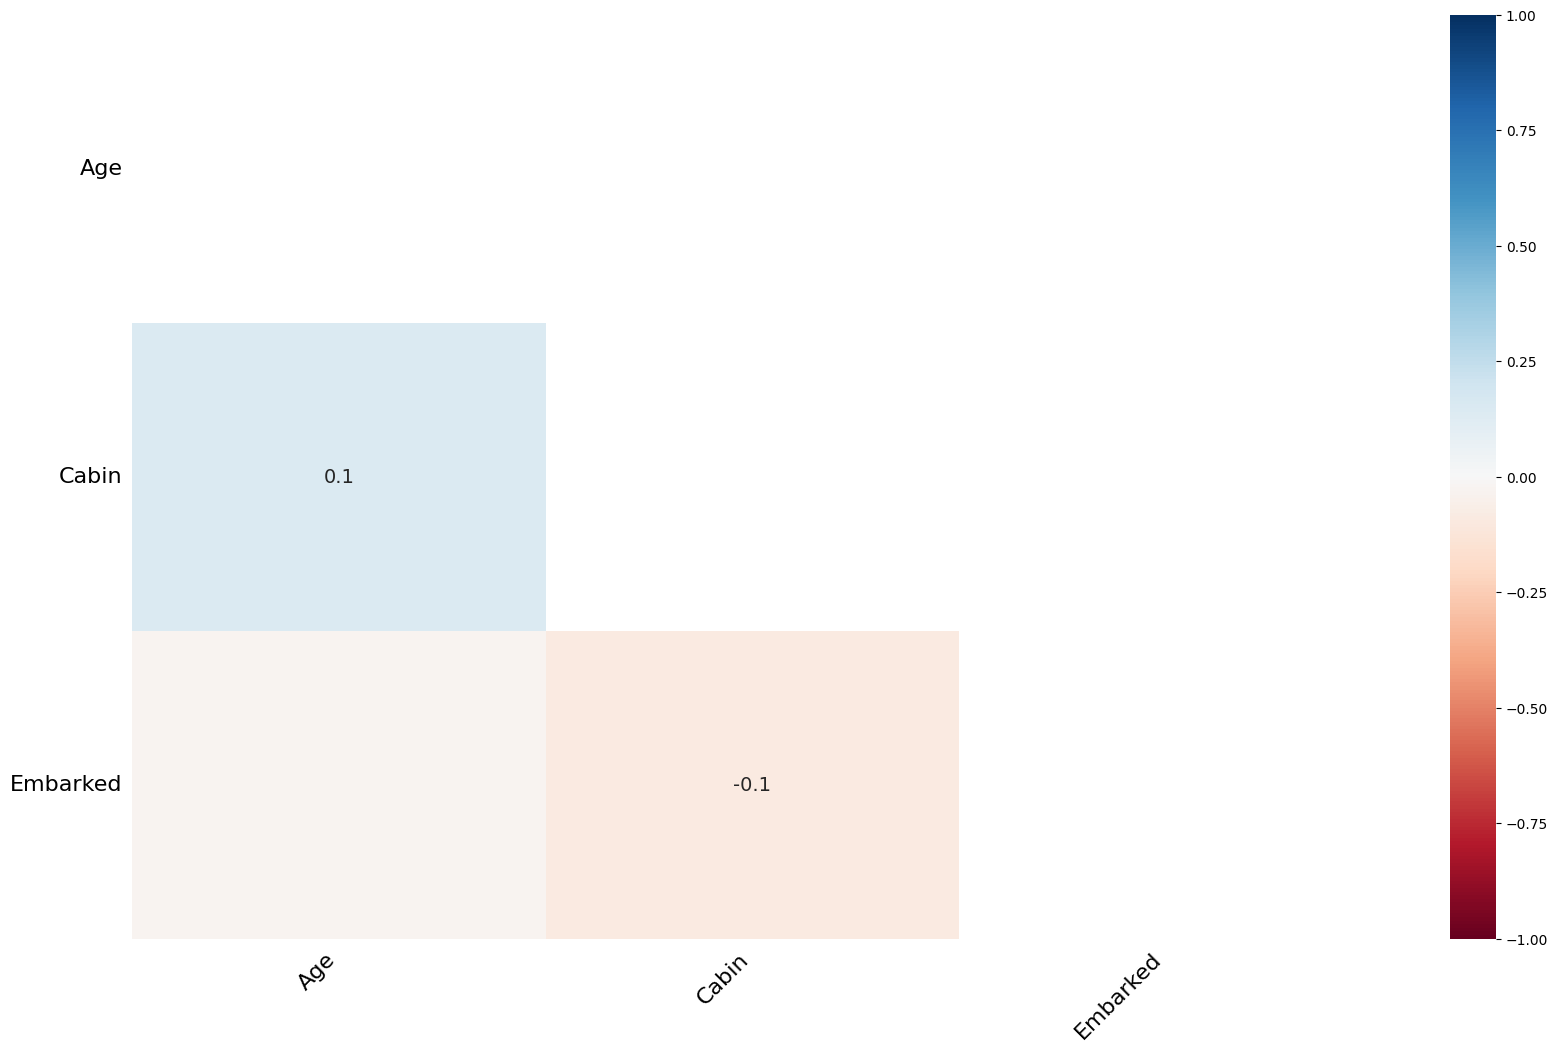

In [10]:
msno.heatmap(titanic_df)

3. Techniques — from basic to advanced

In [29]:
# Listwise — drop any row with a NaN
titanic_clean_df=titanic_df.dropna()

# Columnwise -drop columns with >50 % missing 
threshold=0.5
titanic_clean_df = titanic_df.loc[:, titanic_df.isna().mean() < threshold]
titanic_clean_df


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S
...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C


In [31]:
from sklearn.model_selection import train_test_split
X = titanic_clean_df.drop('Survived', axis=1)
y = titanic_clean_df['Survived']
X_train,X_test,y_train,y_test= train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)
num_cols=titanic_clean_df.select_dtypes(include=np.number).columns.drop(['PassengerId','Survived'])
num_cols

Index(['Pclass', 'Age', 'SibSp', 'Parch', 'Fare'], dtype='object')

Use only for MCAR + small fraction of data. Never in production pipelines without monitoring.

Statistical imputation

In [32]:
from sklearn.impute import SimpleImputer
# Numeric: Mean or median
num_imputer=SimpleImputer(strategy='median') # median is robust to outliers
# Categorical: Most frequent or a constant sentinel 
cat_imputer =SimpleImputer(strategy="most_frequent")
# or # or: SimpleImputer(strategy="constant", fill_value="MISSING")


# # Fit on train, transform both — this is the single most important rule
num_imputer.fit(X_train[num_cols])
X_train[num_cols] = num_imputer.transform(X_train[num_cols])
X_test[num_cols]  = num_imputer.transform(X_test[num_cols])  # ← same fitted para


In [34]:
X_train[num_cols]

,Pclass,Age,SibSp,Parch,Fare
692,3.0,28.5,0.0,0.0,56.4958
481,2.0,28.5,0.0,0.0,0.0000
527,1.0,28.5,0.0,0.0,221.7792
855,3.0,18.0,0.0,1.0,9.3500
801,2.0,31.0,1.0,1.0,26.2500
...,...,...,...,...,...
359,3.0,28.5,0.0,0.0,7.8792
258,1.0,35.0,0.0,0.0,512.3292
736,3.0,48.0,1.0,3.0,34.3750
462,1.0,47.0,0.0,0.0,38.5000


In [35]:
X_test[num_cols]

,Pclass,Age,SibSp,Parch,Fare
565,3.0,24.0,2.0,0.0,24.1500
160,3.0,44.0,0.0,1.0,16.1000
553,3.0,22.0,0.0,0.0,7.2250
860,3.0,41.0,2.0,0.0,14.1083
241,3.0,28.5,1.0,0.0,15.5000
...,...,...,...,...,...
880,2.0,25.0,0.0,1.0,26.0000
91,3.0,20.0,0.0,0.0,7.8542
883,2.0,28.0,0.0,0.0,10.5000
473,2.0,23.0,0.0,0.0,13.7917


When to use: Fast baseline, works well with tree models that handle noise well.



Important :     

# KNN imputation

In [38]:
from sklearn.impute import KNNImputer
import pandas as pd

# Select only numeric columns for KNN
numeric_cols = X_train.select_dtypes(include="number").columns.tolist()

X_train_num = X_train[numeric_cols]
X_test_num  = X_test[numeric_cols]

knn_imp = KNNImputer(n_neighbors=5, weights="distance")
X_train_imp = knn_imp.fit_transform(X_train_num)
X_test_imp  = knn_imp.transform(X_test_num)

# Convert back to DataFrame with column names
X_train_imp = pd.DataFrame(X_train_imp, columns=numeric_cols, index=X_train.index)
X_test_imp  = pd.DataFrame(X_test_imp,  columns=numeric_cols, index=X_test.index)

print("Done. Shape:", X_train_imp.shape)
print("Any NaN left?", X_train_imp.isna().any().any())

Done. Shape: (712, 6)
Any NaN left? False


Important: Use SimpleImputer strategies based on data distribution and type: mean for normally distributed numerical data, median for skewed numerical data or with outliers, and most_frequent (mode) for categorical or skewed ordinal

## KNN impoter will works only on numerical columns. 

You have string columns (like Name) still in your dataframe. Here is the complete fix.

we do have 4 different levels of fixes depends on our situation

### Fix 1 — Quickest: drop non-numeric columns before KNN

In [40]:
from sklearn.impute import KNNImputer
import pandas as pd

# Select only numeric columns for KNN
numeric_cols = X_train.select_dtypes(include="number").columns.tolist()

X_train_num = X_train[numeric_cols]
X_test_num  = X_test[numeric_cols]

knn_imp = KNNImputer(n_neighbors=5, weights="distance")
X_train_imp = knn_imp.fit_transform(X_train_num)
X_test_imp  = knn_imp.transform(X_test_num)

# Convert back to DataFrame with column names
X_train_imp = pd.DataFrame(X_train_imp, columns=numeric_cols, index=X_train.index)
X_test_imp  = pd.DataFrame(X_test_imp,  columns=numeric_cols, index=X_test.index)

print("Done. Shape:", X_train_imp.shape)
print("Any NaN left?", X_train_imp.isna().any().any())

Done. Shape: (712, 6)
Any NaN left? False


### Fix 2 — Better: encode categoricals first, then KNN everything

In [41]:
from sklearn.impute import KNNImputer
from sklearn.preprocessing import OrdinalEncoder
import pandas as pd
import numpy as np

# --- Step 1: separate column types ---
num_cols = X_train.select_dtypes(include="number").columns.tolist()
cat_cols = X_train.select_dtypes(include="object").columns.tolist()

# --- Step 2: drop high-cardinality text (Name, Ticket — useless for KNN) ---
drop_cols = ["Name", "Ticket"]          # free text — no signal for distance
cat_cols  = [c for c in cat_cols if c not in drop_cols]

print("Numeric cols for KNN:", num_cols)
print("Categorical cols (will encode):", cat_cols)

# --- Step 3: ordinal-encode categoricals (NaN-safe) ---
enc = OrdinalEncoder(handle_unknown="use_encoded_value",
                     unknown_value=np.nan,     # keeps NaN as NaN for KNN
                     encoded_missing_value=np.nan)

X_train_cat = enc.fit_transform(X_train[cat_cols])
X_test_cat  = enc.transform(X_test[cat_cols])

# --- Step 4: combine numeric + encoded categorical ---
X_train_combined = np.hstack([
    X_train[num_cols].values,
    X_train_cat
])
X_test_combined = np.hstack([
    X_test[num_cols].values,
    X_test_cat
])

# --- Step 5: KNN impute ---
knn_imp = KNNImputer(n_neighbors=5, weights="distance")
X_train_imp = knn_imp.fit_transform(X_train_combined)
X_test_imp  = knn_imp.transform(X_test_combined)

# --- Step 6: back to DataFrame ---
all_cols = num_cols + cat_cols
X_train_imp = pd.DataFrame(X_train_imp, columns=all_cols, index=X_train.index)
X_test_imp  = pd.DataFrame(X_test_imp,  columns=all_cols, index=X_test.index)

print("Shape:", X_train_imp.shape)
print("NaN remaining:", X_train_imp.isna().sum().sum())

Numeric cols for KNN: ['PassengerId', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare']
Categorical cols (will encode): ['Sex', 'Embarked']
Shape: (712, 8)
NaN remaining: 0


### Fix 3 — Production standard: full sklearn Pipeline

In [42]:
from sklearn.impute import KNNImputer, SimpleImputer
from sklearn.preprocessing import OrdinalEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import pandas as pd
import numpy as np

# ── define your columns ───────────────────────────────────────────
num_cols  = ["Age", "Fare", "SibSp", "Parch"]
cat_cols  = ["Sex", "Embarked", "Pclass"]
drop_cols = ["Name", "Ticket", "Cabin"]          # free text / too sparse

X_train = X_train.drop(columns=drop_cols, errors="ignore")
X_test  = X_test.drop(columns=drop_cols,  errors="ignore")

# ── numeric branch: scale → KNN ───────────────────────────────────
num_pipe = Pipeline([
    ("scale", StandardScaler()),          # KNN needs scaling — distances!
    ("knn",   KNNImputer(n_neighbors=5, weights="distance")),
])

# ── categorical branch: encode → mode fill ────────────────────────
cat_pipe = Pipeline([
    ("encode", OrdinalEncoder(
        handle_unknown="use_encoded_value",
        unknown_value=np.nan,
        encoded_missing_value=np.nan)),
    ("impute", SimpleImputer(strategy="most_frequent")),
])

# ── combine ───────────────────────────────────────────────────────
preprocessor = ColumnTransformer([
    ("num", num_pipe, num_cols),
    ("cat", cat_pipe, cat_cols),
], remainder="drop")

preprocessor.fit(X_train)
X_train_imp = preprocessor.transform(X_train)
X_test_imp  = preprocessor.transform(X_test)

# back to DataFrame
out_cols = num_cols + cat_cols
X_train_imp = pd.DataFrame(X_train_imp, columns=out_cols, index=X_train.index)
X_test_imp  = pd.DataFrame(X_test_imp,  columns=out_cols, index=X_test.index)

print("Train shape:", X_train_imp.shape)
print("NaN left:", X_train_imp.isna().sum().sum())   # should be 0

Train shape: (712, 7)
NaN left: 0
